In [16]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

df = pd.read_csv('benchmark/merged_gausssum_select.csv')

# Classify circuit type from circuit name
def classify(name):
    if 'gausssum' in name: return 'Gaussian Sum'
    if 'treesum' in name: return 'Tree Sum'
    if 'seqsum' in name: return 'Sequential Sum'
    if 'bitonic' in name: return 'Bitonic Sort'
    if 'select' in name: return 'Selection'
    if 'treemech' in name: return 'Tree Mechanism'
    if 'distincthist' in name: return 'Distinct Elements (Histogram)'
    if 'distinct' in name: return 'Distinct Elements'
    if 'lcb' in name: return 'Linear Contextual Bandits'
    return 'Other'

df['circuit_type'] = df['circuit'].apply(classify)

# All costs come from actual measured benchmark data in the CSV:
#   garble_time_us, ot_are_time_us, boundary_time_us  (microseconds)
#   garbled_table_bytes, ot_are_bytes, boundary_bytes  (bytes)
print(f'Loaded {len(df)} rows')
print(f'Experiments: {sorted(df["experiment"].unique())}')
print(f'Circuits: {sorted(df["circuit_type"].unique())}')
print(f'N values: {sorted(df["n_clients"].unique())}')
print(f'Balanced values: {sorted(df["balanced"].unique())}')
df.head()

Loaded 10160 rows
Experiments: ['net_gausssum_N128_min_cut', 'net_gausssum_N128_min_max_in', 'net_gausssum_N128_nonxor_bal', 'net_gausssum_N128_topo_bal', 'net_gausssum_N128_unbal', 'net_gausssum_N16_min_cut', 'net_gausssum_N16_min_max_in', 'net_gausssum_N16_nonxor_bal', 'net_gausssum_N16_topo_bal', 'net_gausssum_N16_unbal', 'net_gausssum_N256_min_cut', 'net_gausssum_N256_min_max_in', 'net_gausssum_N256_nonxor_bal', 'net_gausssum_N256_topo_bal', 'net_gausssum_N256_unbal', 'net_gausssum_N32_min_cut', 'net_gausssum_N32_min_max_in', 'net_gausssum_N32_nonxor_bal', 'net_gausssum_N32_topo_bal', 'net_gausssum_N32_unbal', 'net_gausssum_N512_min_cut', 'net_gausssum_N512_min_max_in', 'net_gausssum_N512_nonxor_bal', 'net_gausssum_N512_topo_bal', 'net_gausssum_N512_unbal', 'net_gausssum_N64_min_cut', 'net_gausssum_N64_min_max_in', 'net_gausssum_N64_nonxor_bal', 'net_gausssum_N64_topo_bal', 'net_gausssum_N64_unbal', 'net_gausssum_N8_min_cut', 'net_gausssum_N8_min_max_in', 'net_gausssum_N8_nonxor_ba

,experiment,n_clients,circuit,circuit_gates,bit_width,balanced,partition_mode,total_boundary_pins,client_id,num_gates,...,num_boundary_out,garble_time_us,ot_are_time_us,boundary_time_us,total_time_us,garbled_table_bytes,ot_are_bytes,boundary_bytes,total_bytes,circuit_type
0,net_gausssum_N8_topo_bal,8,gausssum,291,8,1,topo_bal,75,0,37,...,10,14.566,167563.0,0.0,167578.0,480,245760,0,246240,Gaussian Sum
1,net_gausssum_N8_topo_bal,8,gausssum,291,8,1,topo_bal,75,1,37,...,9,14.457,167713.0,0.0,167728.0,480,245760,0,246240,Gaussian Sum
2,net_gausssum_N8_topo_bal,8,gausssum,291,8,1,topo_bal,75,2,37,...,10,15.552,167591.0,0.0,167607.0,480,245760,0,246240,Gaussian Sum
3,net_gausssum_N8_topo_bal,8,gausssum,291,8,1,topo_bal,75,3,36,...,11,14.339,167586.0,0.0,167600.0,480,245760,0,246240,Gaussian Sum
4,net_gausssum_N8_topo_bal,8,gausssum,291,8,1,topo_bal,75,4,36,...,13,11.730,167661.0,597704.0,765377.0,448,245760,552960,799168,Gaussian Sum


In [17]:
# Aggregate per experiment, keyed by partition_mode (unbal / topo_bal / nonxor_bal / min_cut / min_max_in)
def compute_costs(group):
    n = group['n_clients'].iloc[0]
    circuit = group['circuit'].iloc[0]
    balanced = group['balanced'].iloc[0]
    gates = group['circuit_gates'].iloc[0]
    ct = group['circuit_type'].iloc[0]
    mode = group['partition_mode'].iloc[0]

    total_and = group['num_and'].sum()
    total_inputs = group['num_inputs'].sum()
    total_boundary = group['num_boundary_in'].sum()

    avg_comp_ms = group['total_time_us'].mean() / 1000.0
    max_comp_ms = group['total_time_us'].max() / 1000.0
    avg_comm_KB = group['total_bytes'].mean() / 1024.0
    max_comm_KB = group['total_bytes'].max() / 1024.0

    return pd.Series({
        'n_clients': n, 'circuit': circuit, 'circuit_gates': gates,
        'balanced': balanced, 'circuit_type': ct, 'mode': mode,
        'total_and': total_and, 'total_inputs': total_inputs,
        'total_boundary': total_boundary,
        'avg_comp_ms': avg_comp_ms, 'max_comp_ms': max_comp_ms,
        'avg_comm_KB': avg_comm_KB, 'max_comm_KB': max_comm_KB,
    })

runs = df.groupby('experiment').apply(compute_costs).reset_index()

# Unbalanced baseline (per circuit, per N)
unbal_base = (runs[runs['mode'] == 'unbal']
              .drop_duplicates(subset=['circuit', 'n_clients'], keep='first')
              .set_index(['circuit', 'n_clients'])[['max_comp_ms', 'max_comm_KB', 'avg_comp_ms', 'avg_comm_KB']])
unbal_base.columns = ['unbal_comp_ms', 'unbal_comm_KB', 'unbal_avg_comp_ms', 'unbal_avg_comm_KB']

# All balanced partition modes (only those actually present in the CSV are plotted).
BAL_MODES = ['topo_bal', 'nonxor_bal', 'min_cut', 'min_max_in']
present_modes = set(runs['mode'].unique())
BAL_MODES = [m for m in BAL_MODES if m in present_modes]
bal_runs = runs[runs['mode'].isin(BAL_MODES)].copy()
bal_runs = bal_runs.drop_duplicates(subset=['circuit', 'n_clients', 'mode'], keep='first')
bal_runs = bal_runs.join(unbal_base, on=['circuit', 'n_clients'])
bal_runs['comp_speedup'] = bal_runs['unbal_comp_ms'] / bal_runs['avg_comp_ms']
bal_runs['comm_speedup'] = bal_runs['unbal_comm_KB'] / bal_runs['avg_comm_KB']

print(f'Partition modes present: {sorted(runs["mode"].unique())}')
for ct in sorted(bal_runs['circuit_type'].unique()):
    print(f'\n--- {ct} ---')
    for m in BAL_MODES:
        sub = bal_runs[(bal_runs['circuit_type'] == ct) & (bal_runs['mode'] == m)].sort_values('n_clients')
        if len(sub) == 0:
            continue
        print(f'  [{m}]')
        for _, row in sub.iterrows():
            print(f"    N={int(row['n_clients']):3d}  avg={row['avg_comp_ms']:.1f}ms  "
                  f"max={row['max_comp_ms']:.1f}ms  unbal={row['unbal_comp_ms']:.1f}ms")


Partition modes present: ['min_cut', 'min_max_in', 'nonxor_bal', 'topo_bal', 'unbal']

--- Gaussian Sum ---
  [topo_bal]
    N=  8  avg=478.0ms  max=828.7ms  unbal=1337.5ms
    N= 16  avg=531.9ms  max=829.5ms  unbal=2676.6ms
    N= 32  avg=557.6ms  max=862.2ms  unbal=5349.2ms
    N= 64  avg=564.4ms  max=894.8ms  unbal=10680.5ms
    N=128  avg=571.2ms  max=895.6ms  unbal=21341.7ms
    N=256  avg=574.7ms  max=927.6ms  unbal=42637.7ms
    N=512  avg=577.0ms  max=993.0ms  unbal=85778.5ms
  [nonxor_bal]
    N=  8  avg=491.1ms  max=828.9ms  unbal=1337.5ms
    N= 16  avg=527.8ms  max=894.7ms  unbal=2676.6ms
    N= 32  avg=549.3ms  max=927.0ms  unbal=5349.2ms
    N= 64  avg=567.7ms  max=992.6ms  unbal=10680.5ms
    N=128  avg=573.9ms  max=1025.9ms  unbal=21341.7ms
    N=256  avg=571.2ms  max=1058.2ms  unbal=42637.7ms
    N=512  avg=575.8ms  max=1091.3ms  unbal=85778.5ms
  [min_cut]
    N=  8  avg=490.7ms  max=828.7ms  unbal=1337.5ms
    N= 16  avg=523.7ms  max=894.8ms  unbal=2676.6ms
    N= 32

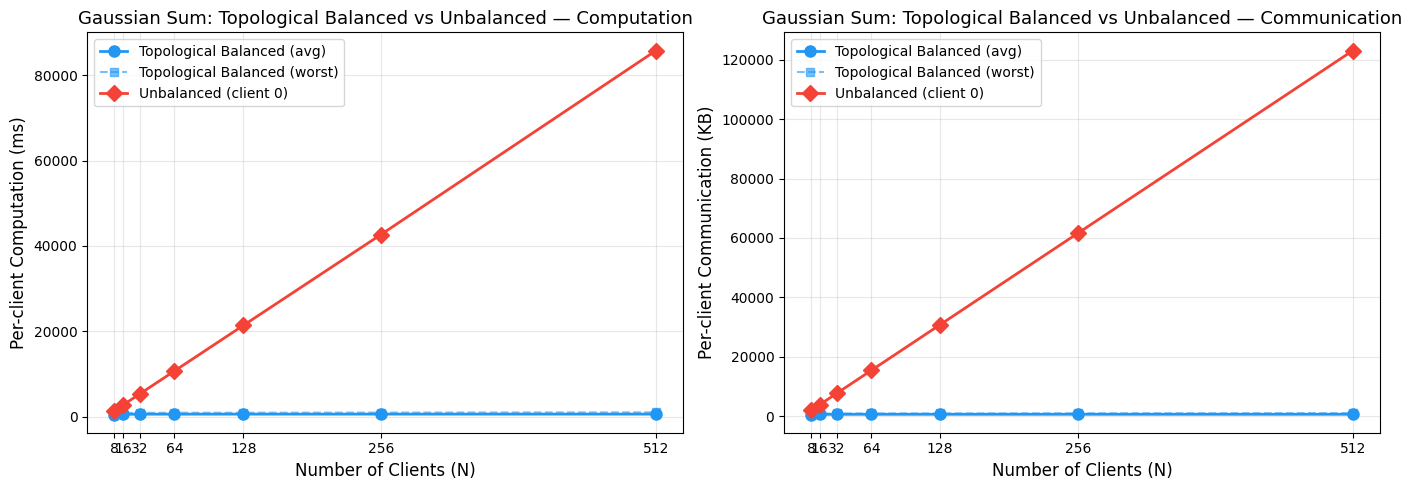

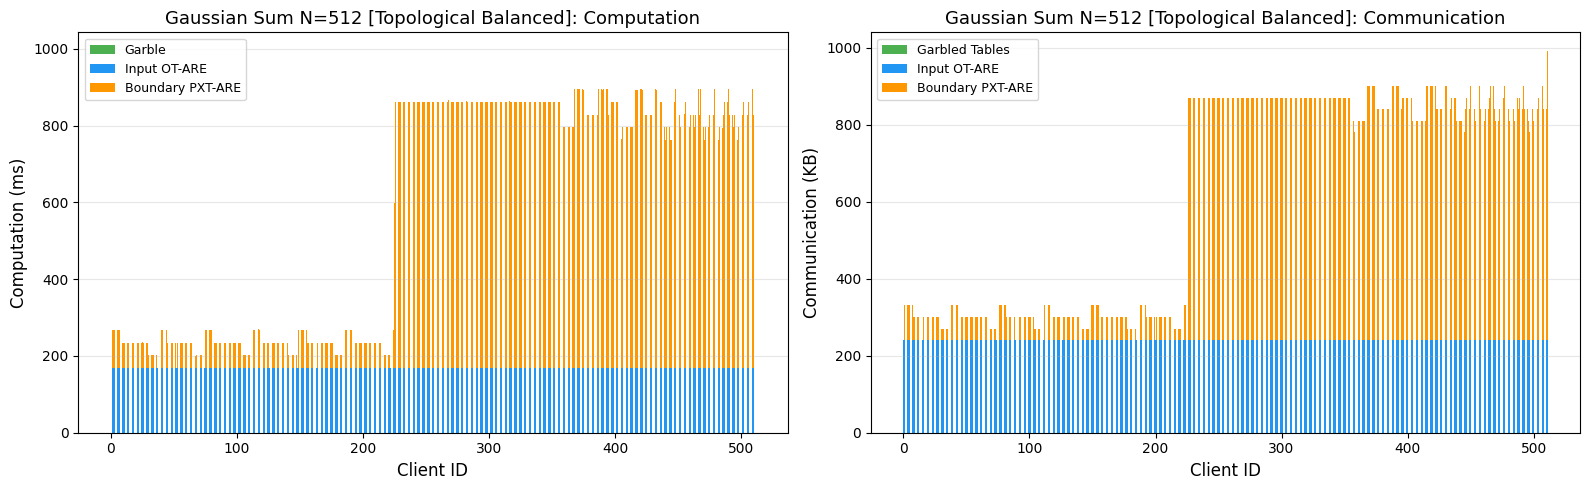

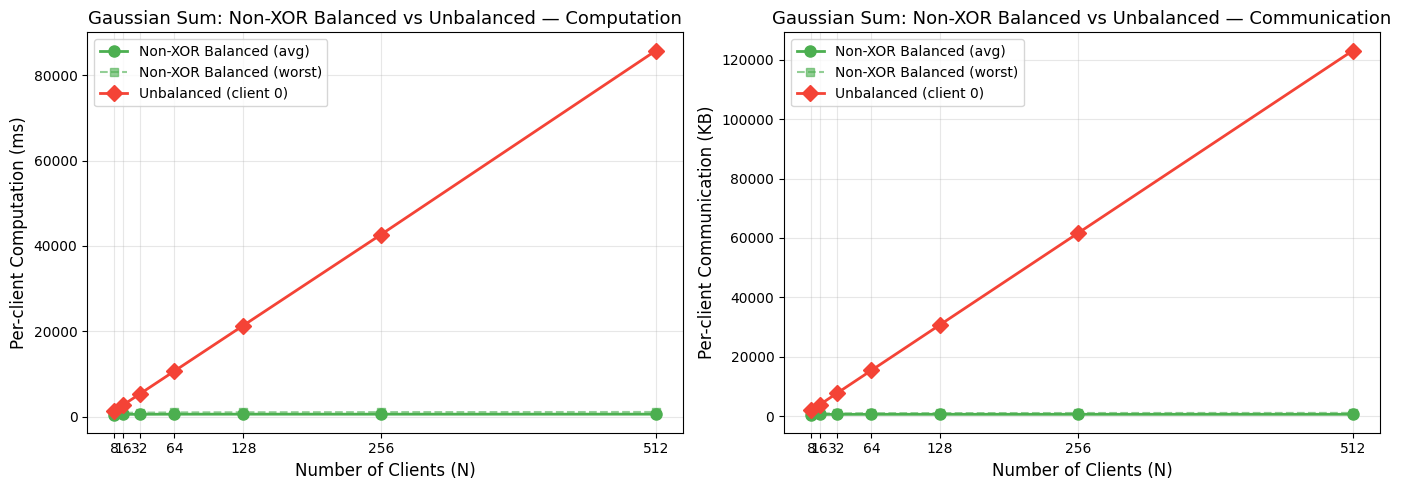

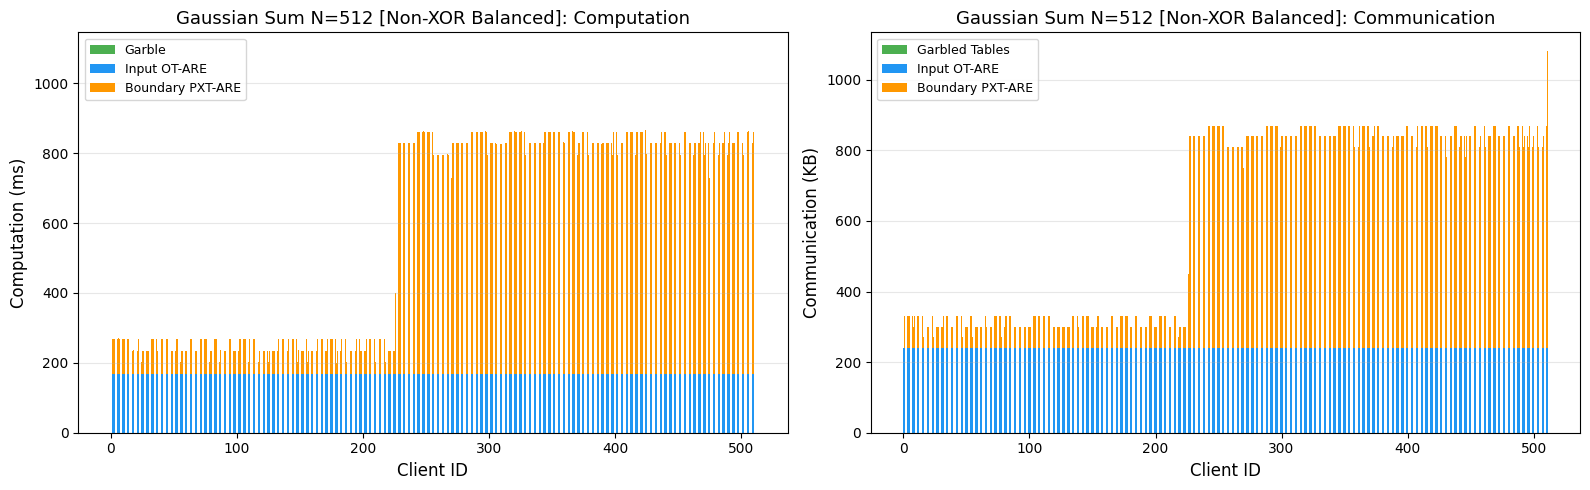

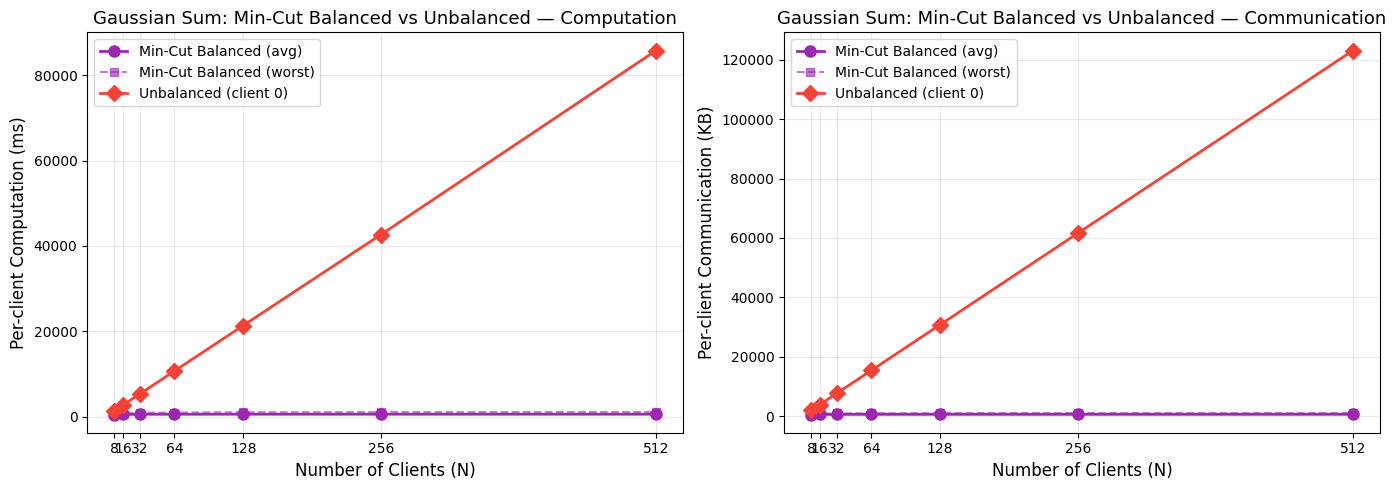

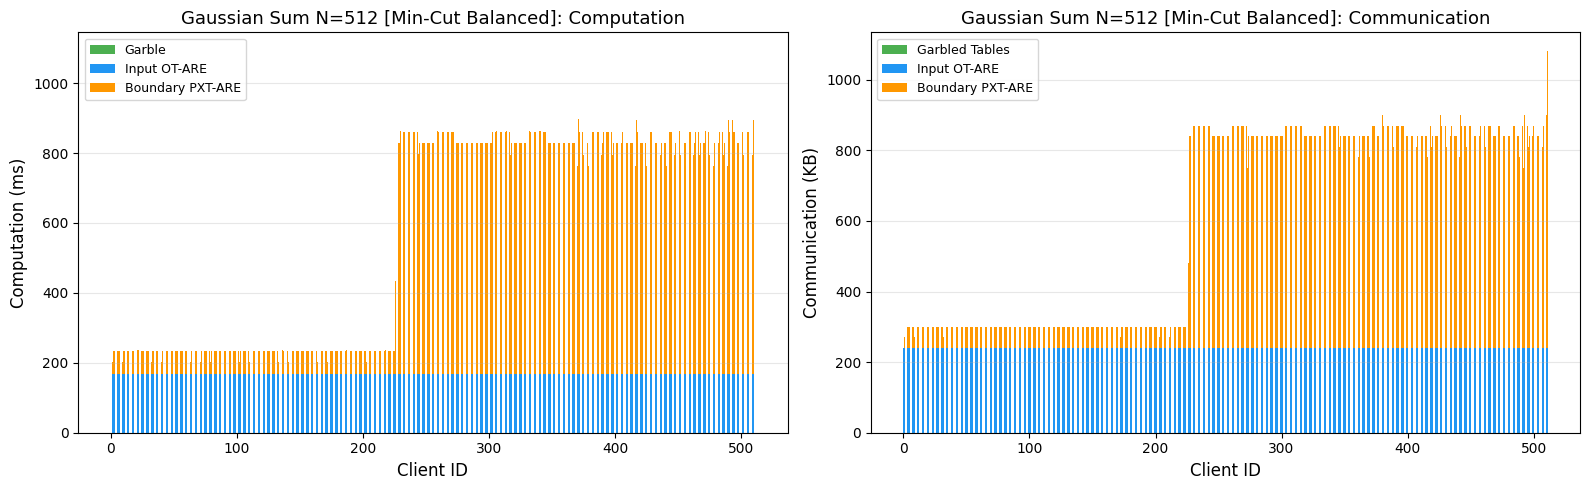

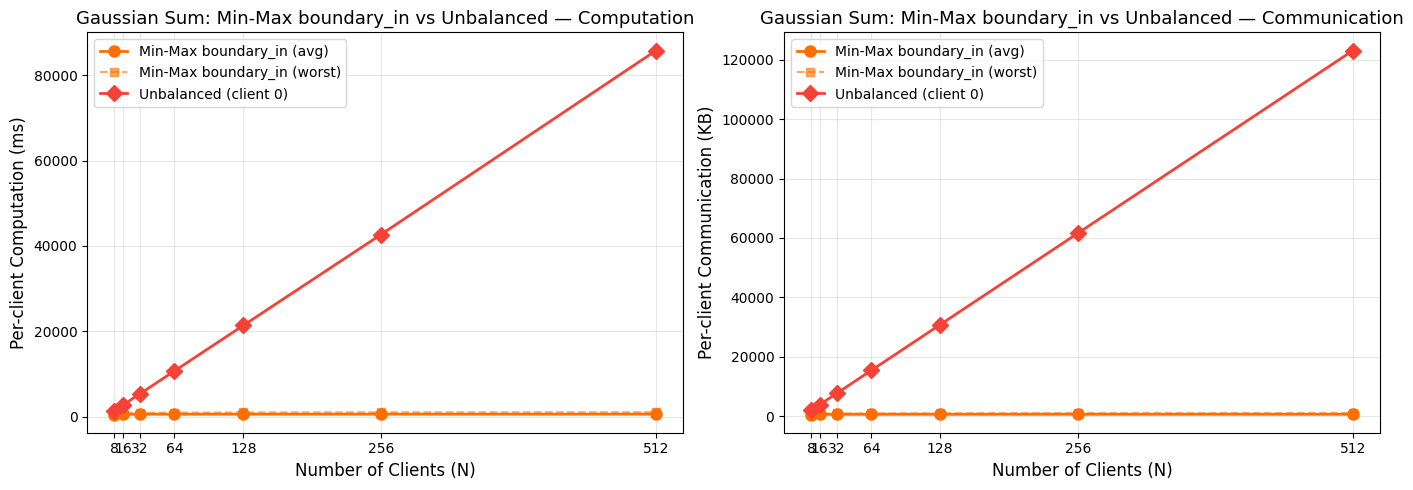

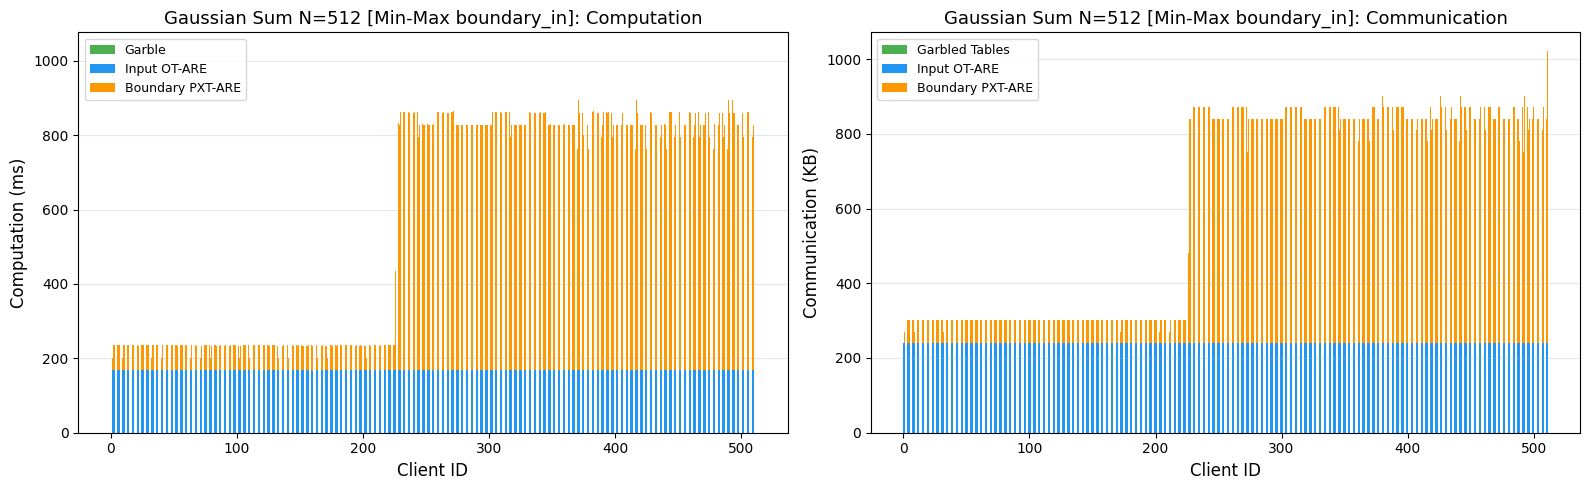

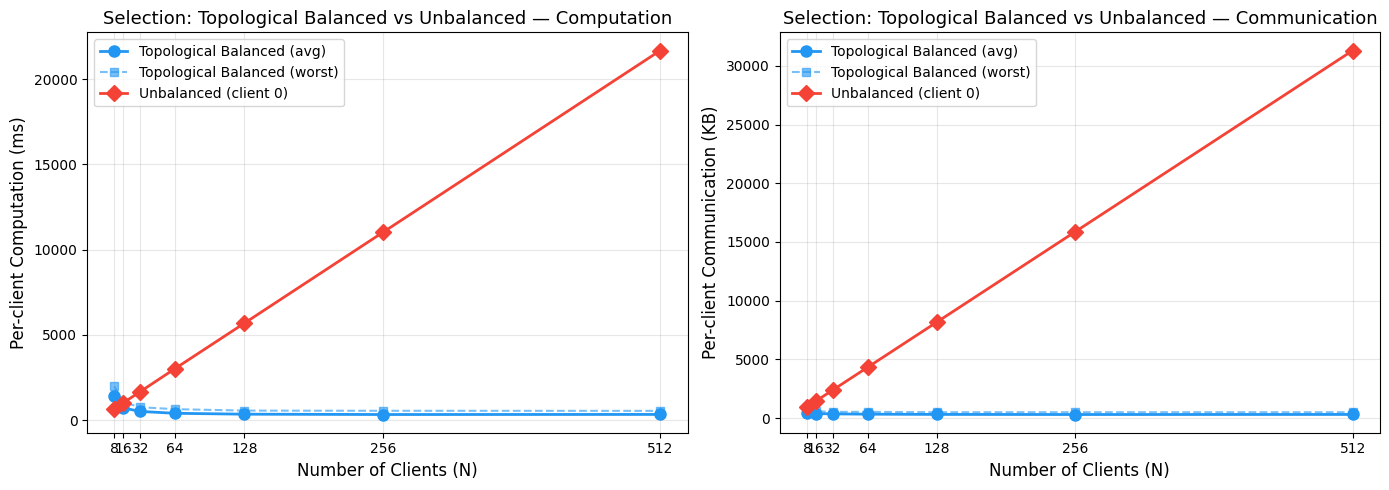

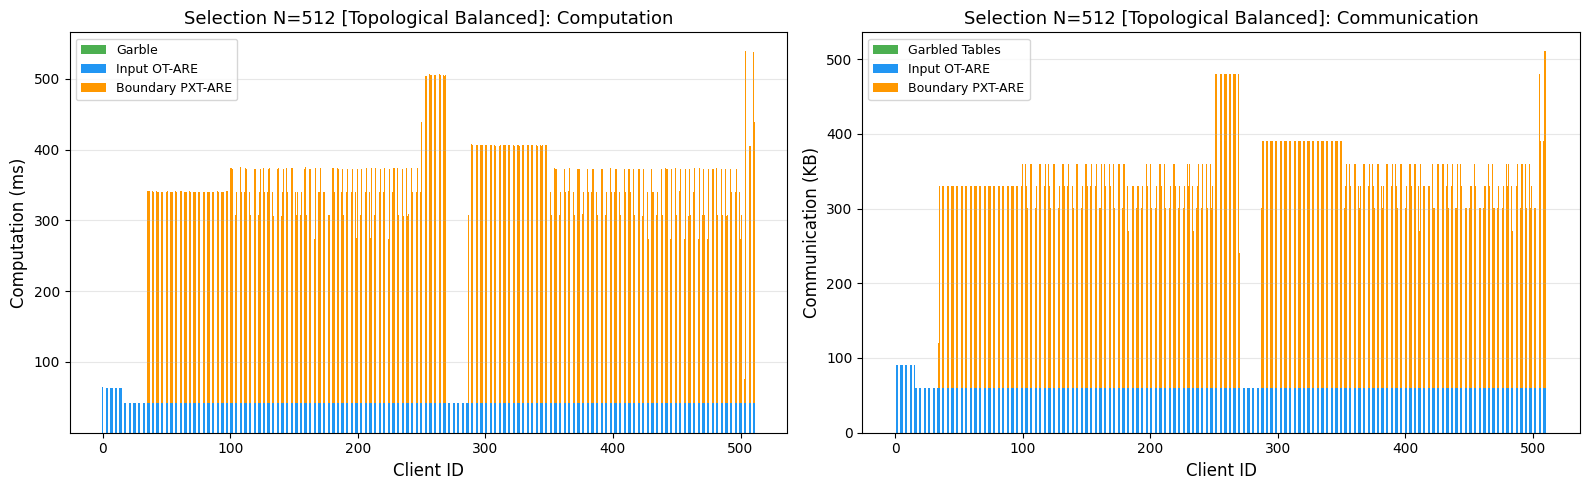

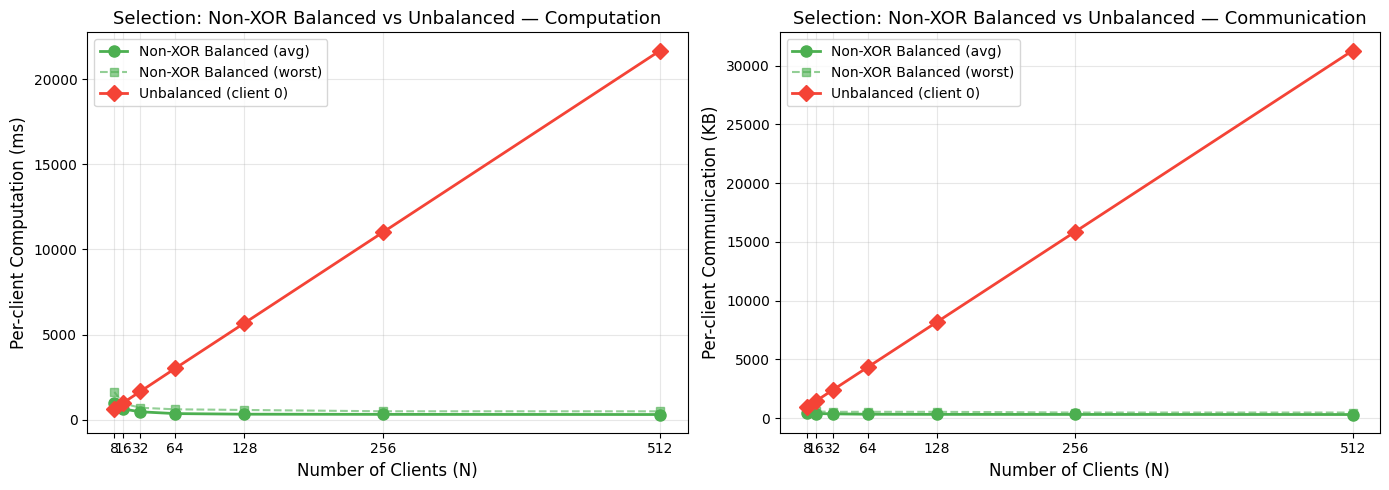

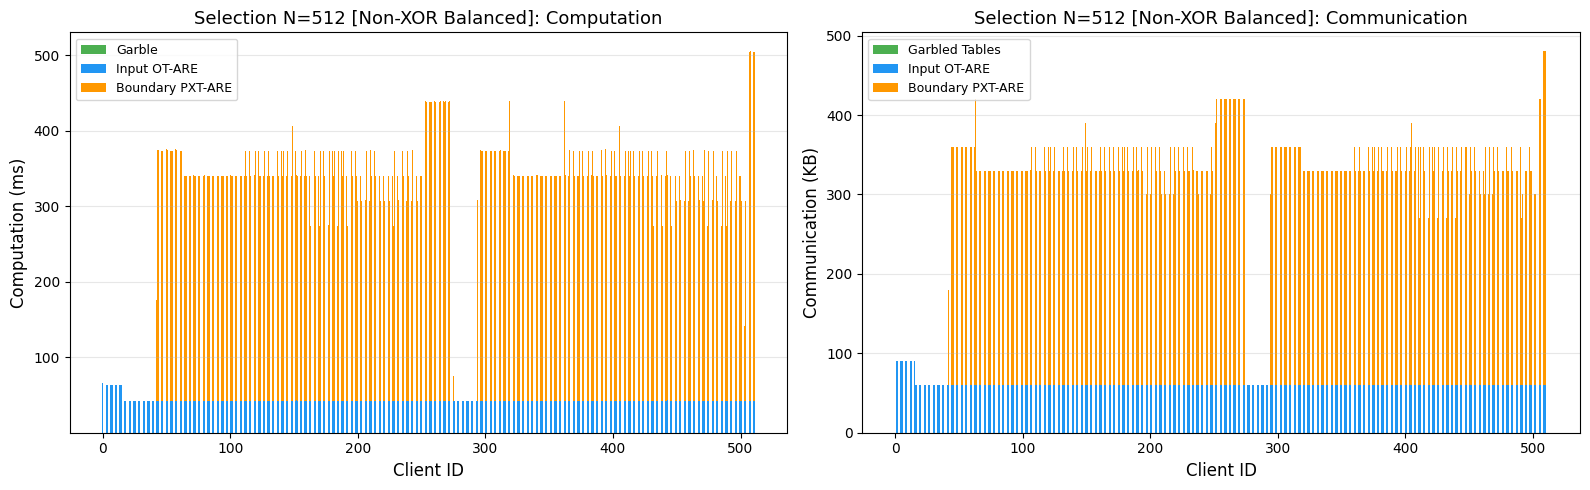

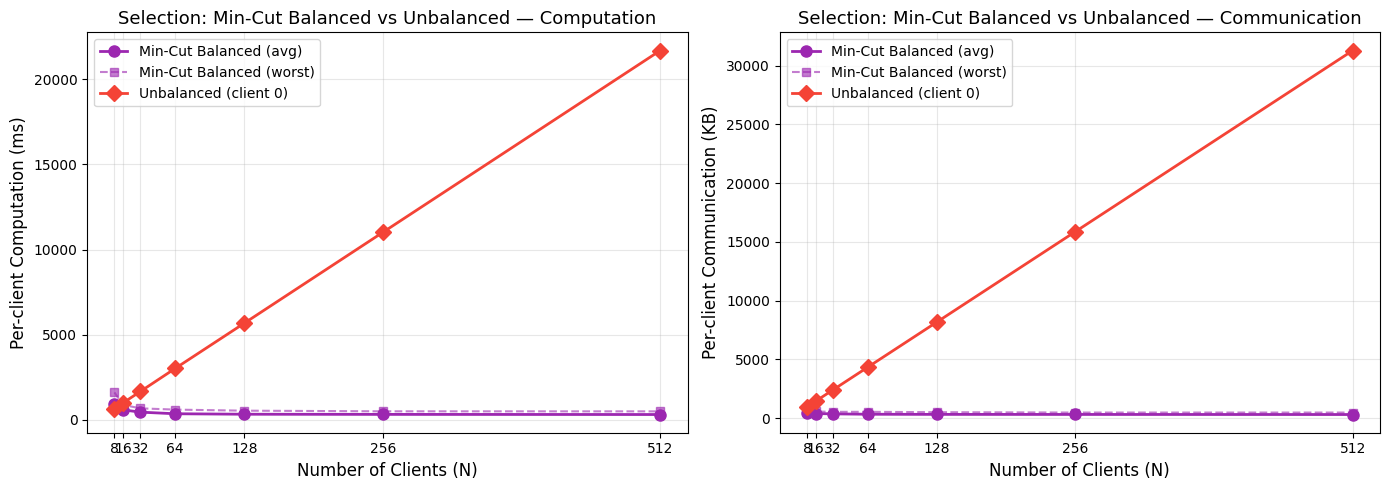

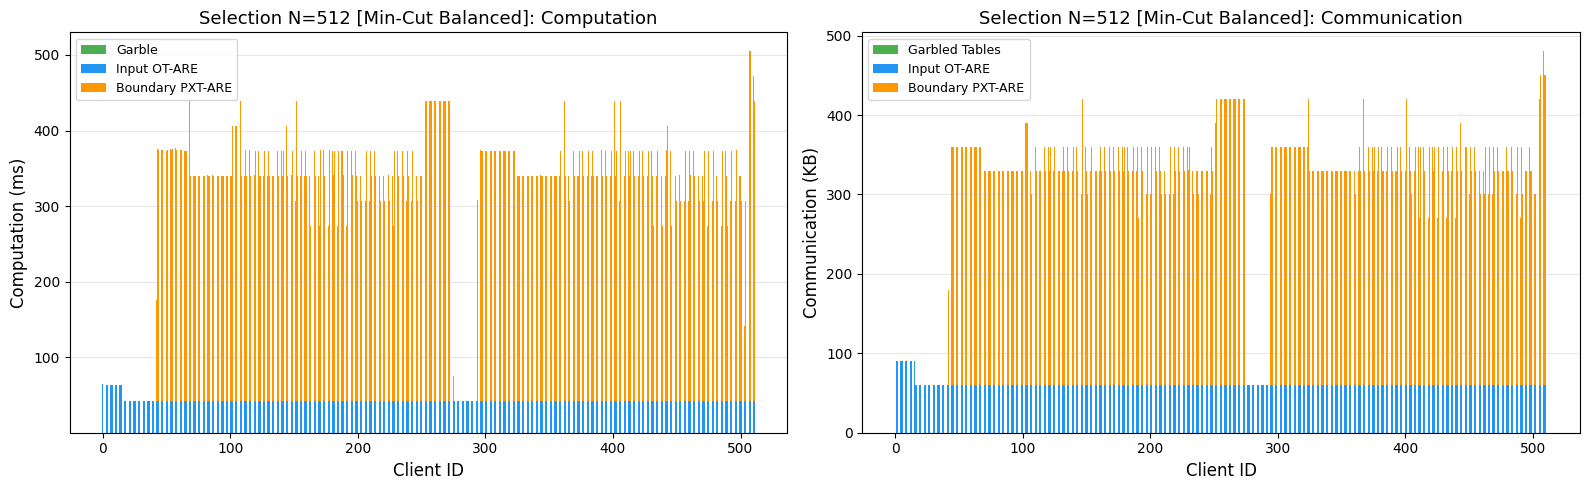

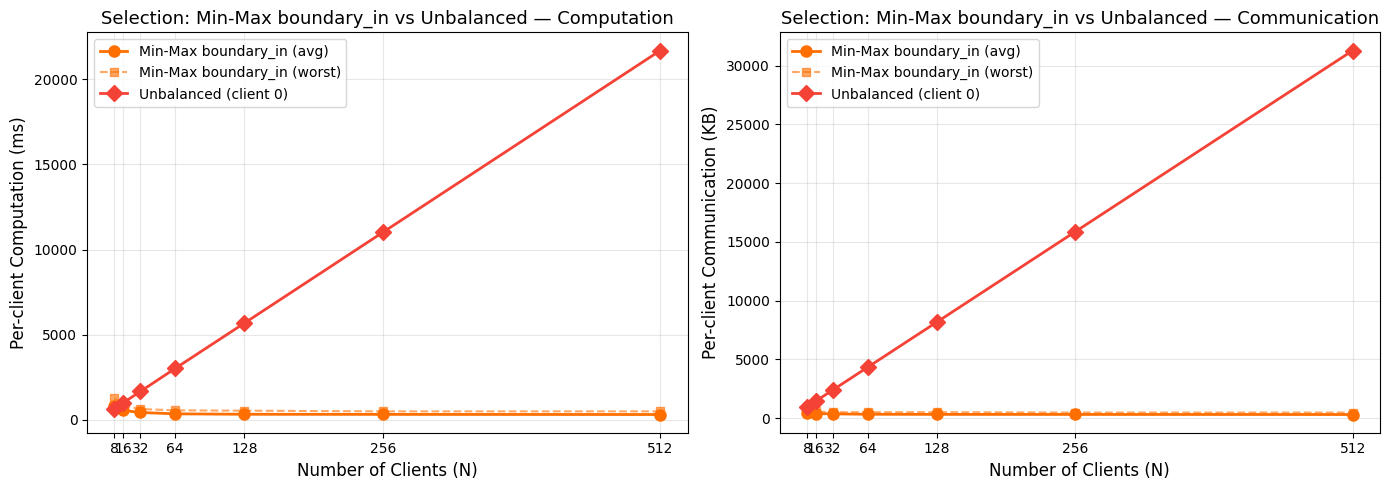

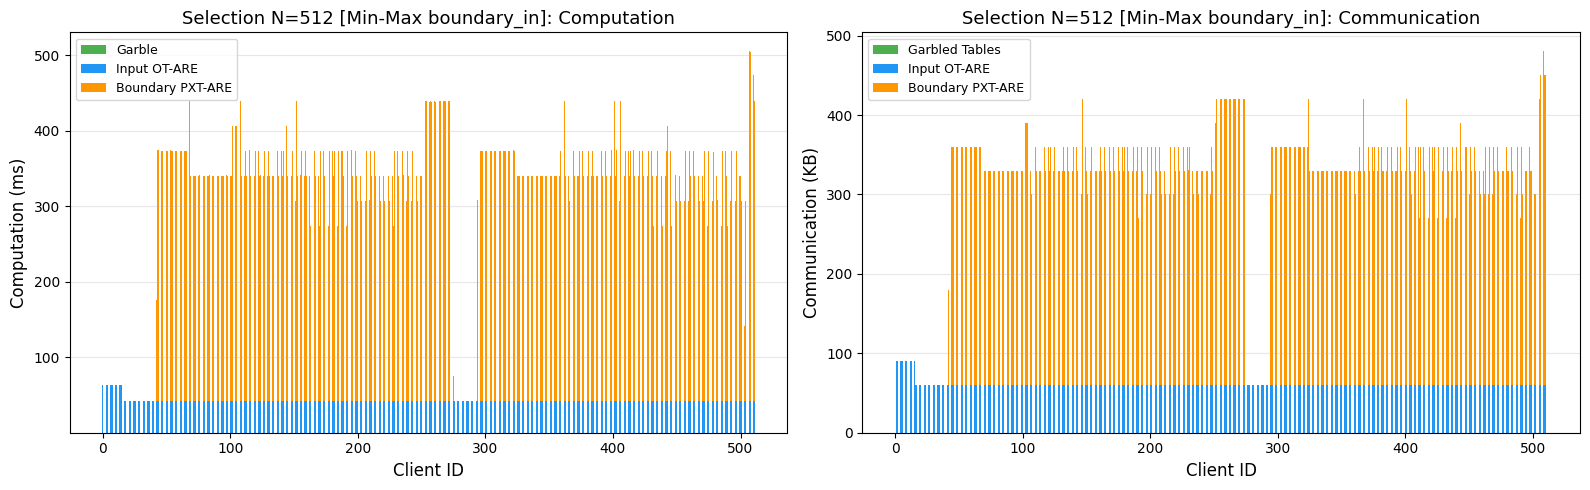

In [18]:
# ── Per-circuit plots: one figure per (partition-mode vs unbalanced) ───────────
# Each balancing strategy gets its OWN plot vs unbalanced — nothing is overlaid
# across balancing modes.

MODE_LABELS = {
    'topo_bal':   'Topological Balanced',
    'nonxor_bal': 'Non-XOR Balanced',
    'min_cut':    'Min-Cut Balanced',
    'min_max_in': 'Min-Max boundary_in',
}
MODE_COLORS = {
    'topo_bal':   '#2196F3',
    'nonxor_bal': '#4CAF50',
    'min_cut':    '#9C27B0',
    'min_max_in': '#FF6F00',
}

circuit_types = sorted(bal_runs['circuit_type'].unique())

for ct in circuit_types:
    for mode in BAL_MODES:
        sub = bal_runs[(bal_runs['circuit_type'] == ct) & (bal_runs['mode'] == mode)].sort_values('n_clients')
        if len(sub) == 0:
            continue

        label = MODE_LABELS[mode]
        color = MODE_COLORS[mode]
        x = sub['n_clients'].values

        fig, axes = plt.subplots(1, 2, figsize=(14, 5))

        # --- Computation ---
        axes[0].plot(x, sub['avg_comp_ms'], 'o-', color=color, linewidth=2, markersize=8, label=f'{label} (avg)')
        axes[0].plot(x, sub['max_comp_ms'], 's--', color=color, linewidth=1.5, markersize=6, alpha=0.6, label=f'{label} (worst)')
        axes[0].plot(x, sub['unbal_comp_ms'], 'D-', color='#F44336', linewidth=2, markersize=8, label='Unbalanced (client 0)')
        axes[0].set_xlabel('Number of Clients (N)', fontsize=12)
        axes[0].set_ylabel('Per-client Computation (ms)', fontsize=12)
        axes[0].set_title(f'{ct}: {label} vs Unbalanced — Computation', fontsize=13)
        axes[0].set_xticks(x)
        axes[0].legend(fontsize=10)
        axes[0].grid(True, alpha=0.3)

        # --- Communication ---
        axes[1].plot(x, sub['avg_comm_KB'], 'o-', color=color, linewidth=2, markersize=8, label=f'{label} (avg)')
        axes[1].plot(x, sub['max_comm_KB'], 's--', color=color, linewidth=1.5, markersize=6, alpha=0.6, label=f'{label} (worst)')
        axes[1].plot(x, sub['unbal_comm_KB'], 'D-', color='#F44336', linewidth=2, markersize=8, label='Unbalanced (client 0)')
        axes[1].set_xlabel('Number of Clients (N)', fontsize=12)
        axes[1].set_ylabel('Per-client Communication (KB)', fontsize=12)
        axes[1].set_title(f'{ct}: {label} vs Unbalanced — Communication', fontsize=13)
        axes[1].set_xticks(x)
        axes[1].legend(fontsize=10)
        axes[1].grid(True, alpha=0.3)

        plt.tight_layout()
        plt.show()

        # --- Per-client breakdown for largest N under this mode ---
        circ_key = sub['circuit'].iloc[0]
        max_n = int(sub['n_clients'].max())
        exp_name = f'net_{circ_key}_N{max_n}_{mode}'
        breakdown = df[df['experiment'] == exp_name].sort_values('client_id')
        if len(breakdown) == 0:
            continue
        fig, axes = plt.subplots(1, 2, figsize=(16, 5))
        xb = breakdown['client_id'].values
        w = 0.6 if max_n <= 8 else 0.5
        garble_t = breakdown['garble_time_us'].values / 1000.0
        input_t = breakdown['ot_are_time_us'].values / 1000.0
        boundary_t = breakdown['boundary_time_us'].values / 1000.0
        axes[0].bar(xb, garble_t, w, label='Garble', color='#4CAF50')
        axes[0].bar(xb, input_t, w, bottom=garble_t, label='Input OT-ARE', color='#2196F3')
        axes[0].bar(xb, boundary_t, w, bottom=garble_t+input_t, label='Boundary PXT-ARE', color='#FF9800')
        axes[0].set_xlabel('Client ID', fontsize=12)
        axes[0].set_ylabel('Computation (ms)', fontsize=12)
        axes[0].set_title(f'{ct} N={max_n} [{label}]: Computation', fontsize=13)
        axes[0].legend(fontsize=9)
        axes[0].grid(True, alpha=0.3, axis='y')
        garble_c = breakdown['garbled_table_bytes'].values / 1024.0
        input_c = breakdown['ot_are_bytes'].values / 1024.0
        boundary_c = breakdown['boundary_bytes'].values / 1024.0
        axes[1].bar(xb, garble_c, w, label='Garbled Tables', color='#4CAF50')
        axes[1].bar(xb, input_c, w, bottom=garble_c, label='Input OT-ARE', color='#2196F3')
        axes[1].bar(xb, boundary_c, w, bottom=garble_c+input_c, label='Boundary PXT-ARE', color='#FF9800')
        axes[1].set_xlabel('Client ID', fontsize=12)
        axes[1].set_ylabel('Communication (KB)', fontsize=12)
        axes[1].set_title(f'{ct} N={max_n} [{label}]: Communication', fontsize=13)
        axes[1].legend(fontsize=9)
        axes[1].grid(True, alpha=0.3, axis='y')
        plt.tight_layout()
        plt.show()


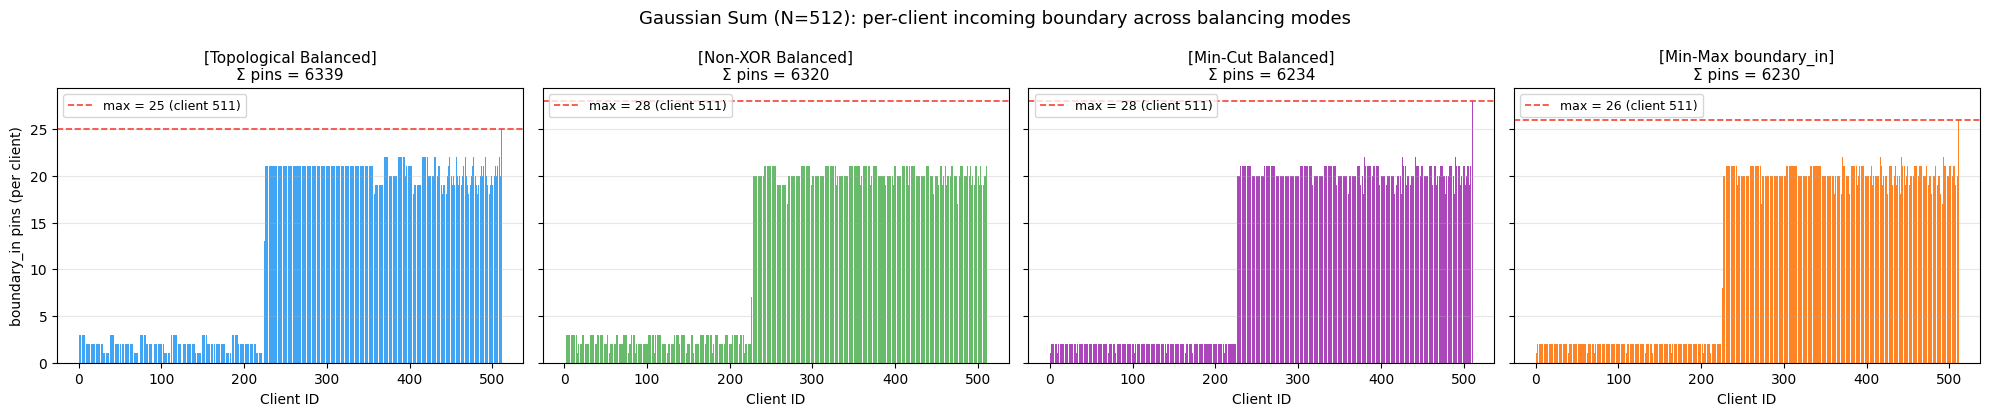

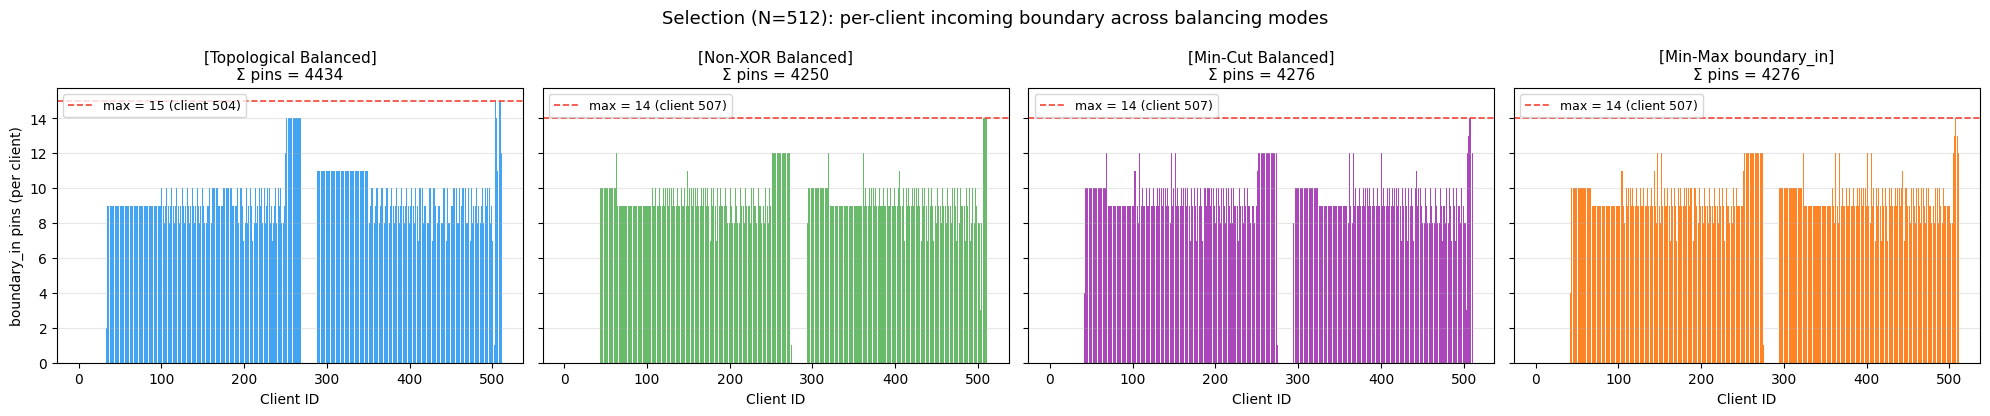

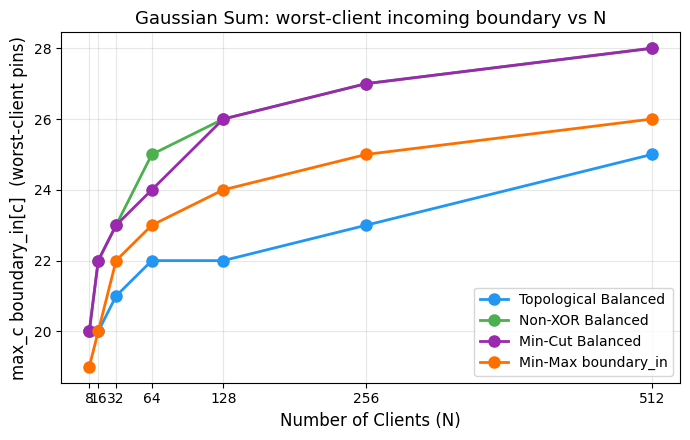

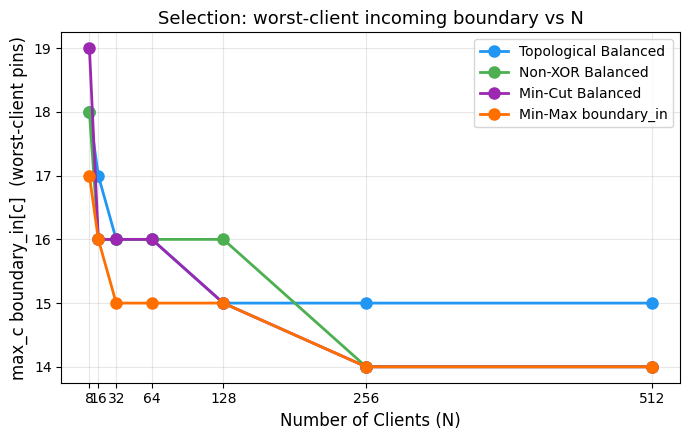

In [19]:
# ── Per-client boundary distribution across modes (paper Problem 1 vs Problem 2) ─
# For each circuit at the largest N, plot per-client boundary_in across the
# balancing modes. The "max bar" is what the protocol actually waits on —
# `min_max_in` (paper Problem 2 with μ_in) targets exactly this max, while
# `min_cut` (Problem 1) only minimises the global sum.

n_modes = len(BAL_MODES)

for ct in sorted(bal_runs['circuit_type'].unique()):
    ct_rows = bal_runs[bal_runs['circuit_type'] == ct]
    if len(ct_rows) == 0: continue
    circ_key = ct_rows['circuit'].iloc[0]
    max_n = int(ct_rows['n_clients'].max())

    fig, axes = plt.subplots(1, n_modes, figsize=(5 * n_modes, 4.2), sharey=True, squeeze=False)
    axes = axes[0]
    for ax, mode in zip(axes, BAL_MODES):
        exp_name = f'net_{circ_key}_N{max_n}_{mode}'
        sub = df[df['experiment'] == exp_name].sort_values('client_id')
        if len(sub) == 0:
            ax.set_title(f'[{MODE_LABELS[mode]}] (no data)')
            continue
        x = sub['client_id'].values
        b_in = sub['num_boundary_in'].values
        max_pin = b_in.max()
        max_client = int(x[b_in.argmax()])
        ax.bar(x, b_in, color=MODE_COLORS[mode], alpha=0.85)
        ax.axhline(max_pin, color='#F44336', linestyle='--', linewidth=1.2,
                   label=f'max = {max_pin} (client {max_client})')
        ax.set_xlabel('Client ID')
        ax.set_title(f'[{MODE_LABELS[mode]}]\nΣ pins = {int(b_in.sum())}', fontsize=11)
        ax.legend(fontsize=9, loc='upper left')
        ax.grid(True, alpha=0.3, axis='y')
    axes[0].set_ylabel('boundary_in pins (per client)')
    fig.suptitle(f'{ct} (N={max_n}): per-client incoming boundary across balancing modes', fontsize=13)
    plt.tight_layout()
    plt.show()

# ── Worst-client pin count vs N (the metric min_max_in minimises) ─────────────
for ct in sorted(bal_runs['circuit_type'].unique()):
    ct_rows = bal_runs[bal_runs['circuit_type'] == ct]
    if len(ct_rows) == 0: continue
    circ_key = ct_rows['circuit'].iloc[0]
    fig, ax = plt.subplots(figsize=(7, 4.5))
    for mode in BAL_MODES:
        ns, max_pins = [], []
        for n in sorted(df['n_clients'].unique()):
            exp_name = f'net_{circ_key}_N{n}_{mode}'
            sub = df[df['experiment'] == exp_name]
            if len(sub) == 0: continue
            ns.append(int(n))
            max_pins.append(int(sub['num_boundary_in'].max()))
        if ns:
            ax.plot(ns, max_pins, 'o-', color=MODE_COLORS[mode], linewidth=2,
                    markersize=8, label=MODE_LABELS[mode])
    ax.set_xlabel('Number of Clients (N)', fontsize=12)
    ax.set_ylabel('max_c boundary_in[c]  (worst-client pins)', fontsize=12)
    ax.set_title(f'{ct}: worst-client incoming boundary vs N', fontsize=13)
    ax.legend(fontsize=10)
    ax.grid(True, alpha=0.3)
    ax.set_xticks(sorted(df['n_clients'].unique()))
    plt.tight_layout()
    plt.show()


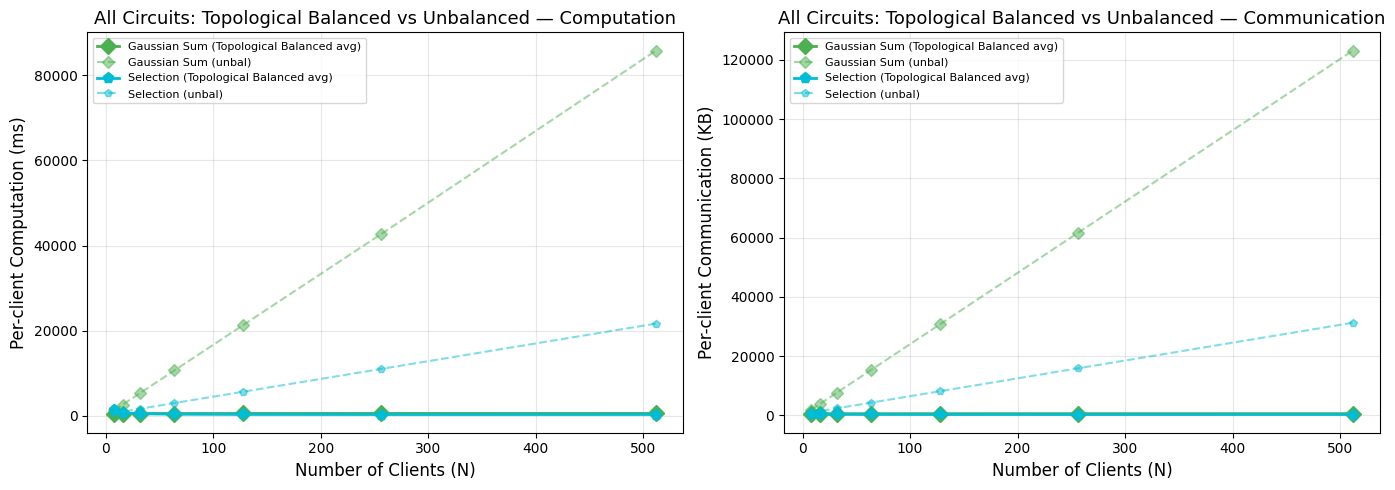

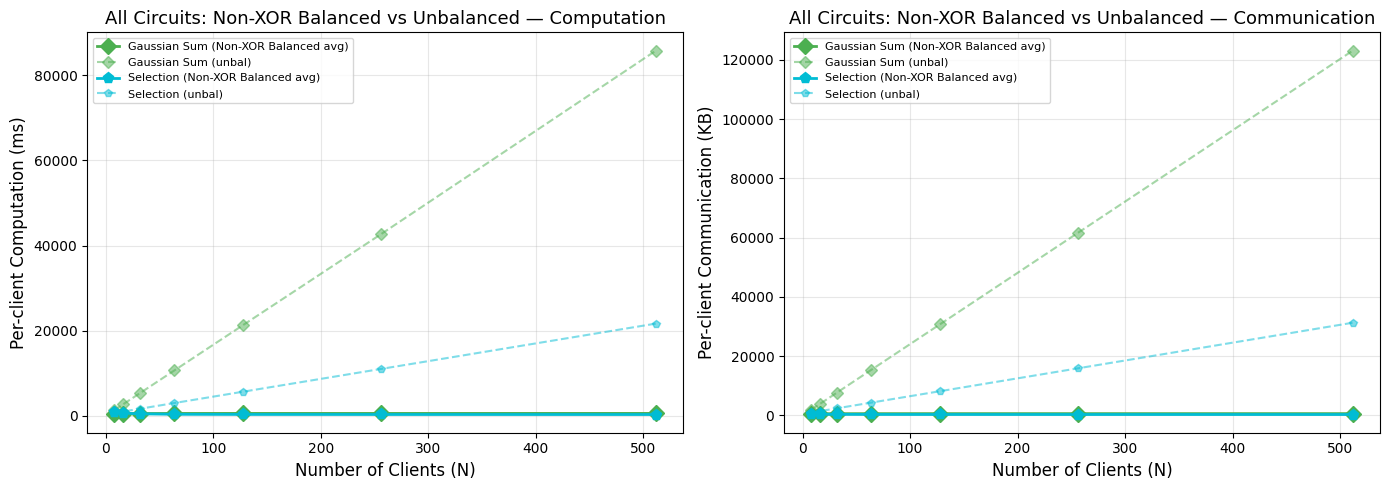

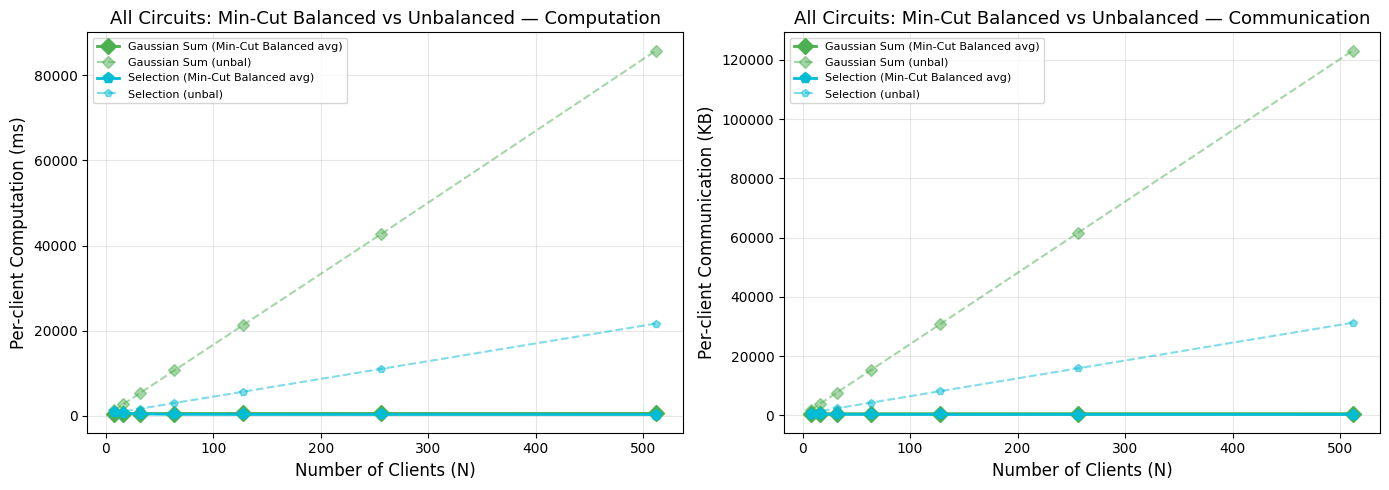

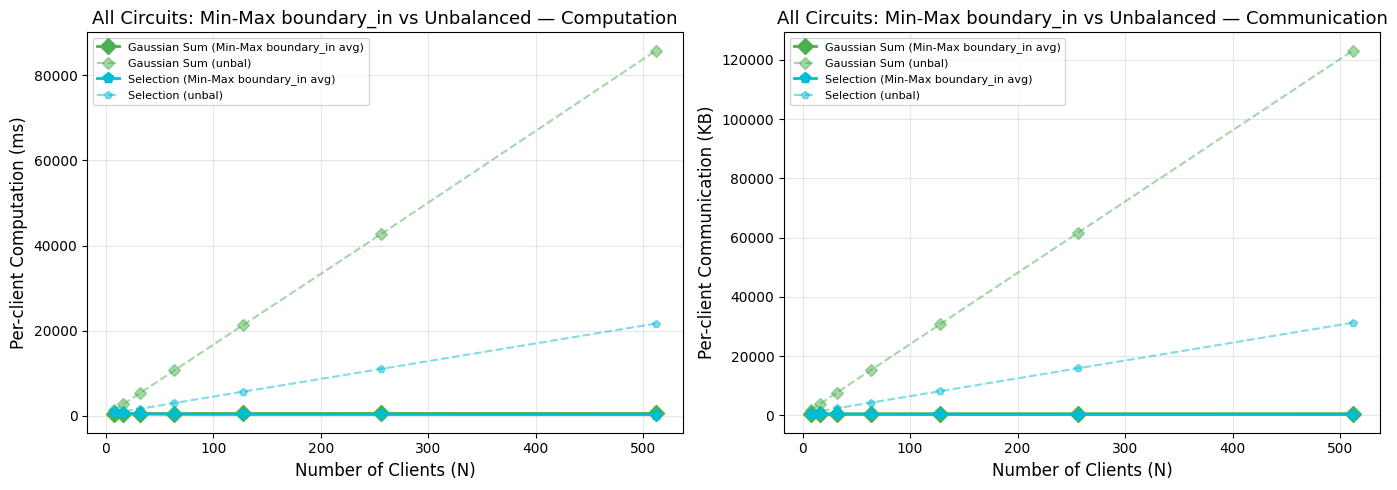

In [20]:
# ── All-circuits overlay: one figure per balancing mode vs unbalanced ──────────
# Keeps the cross-circuit view but plots each balancing strategy separately.
circuit_types = sorted(bal_runs['circuit_type'].unique())
colors_ct = {'Sequential Sum': '#2196F3', 'Tree Sum': '#FF9800', 'Gaussian Sum': '#4CAF50',
             'Tree Mechanism': '#E91E63', 'Bitonic Sort': '#9C27B0', 'Selection': '#00BCD4',
             'Linear Contextual Bandits': '#795548', 'Distinct Elements': '#3F51B5'}
markers_ct = {'Sequential Sum': 'o', 'Tree Sum': 's', 'Gaussian Sum': 'D',
              'Tree Mechanism': '^', 'Bitonic Sort': 'v', 'Selection': 'p',
              'Linear Contextual Bandits': '*', 'Distinct Elements': 'X'}

if len(circuit_types) > 1:
    for mode in BAL_MODES:
        mode_rows = bal_runs[bal_runs['mode'] == mode]
        if len(mode_rows) == 0:
            continue
        label = MODE_LABELS[mode]

        fig, axes = plt.subplots(1, 2, figsize=(14, 5))
        for ct in circuit_types:
            sub = mode_rows[mode_rows['circuit_type'] == ct].sort_values('n_clients')
            if len(sub) == 0: continue
            x = sub['n_clients'].values
            m = markers_ct.get(ct, 'o')
            c = colors_ct.get(ct, 'gray')
            axes[0].plot(x, sub['avg_comp_ms'], f'{m}-', color=c, linewidth=2, markersize=8, label=f'{ct} ({label} avg)')
            axes[0].plot(x, sub['unbal_comp_ms'], f'{m}--', color=c, linewidth=1.5, markersize=6, alpha=0.5, label=f'{ct} (unbal)')
            axes[1].plot(x, sub['avg_comm_KB'], f'{m}-', color=c, linewidth=2, markersize=8, label=f'{ct} ({label} avg)')
            axes[1].plot(x, sub['unbal_comm_KB'], f'{m}--', color=c, linewidth=1.5, markersize=6, alpha=0.5, label=f'{ct} (unbal)')

        axes[0].set_xlabel('Number of Clients (N)', fontsize=12)
        axes[0].set_ylabel('Per-client Computation (ms)', fontsize=12)
        axes[0].set_title(f'All Circuits: {label} vs Unbalanced — Computation', fontsize=13)
        axes[0].legend(fontsize=8)
        axes[0].grid(True, alpha=0.3)

        axes[1].set_xlabel('Number of Clients (N)', fontsize=12)
        axes[1].set_ylabel('Per-client Communication (KB)', fontsize=12)
        axes[1].set_title(f'All Circuits: {label} vs Unbalanced — Communication', fontsize=13)
        axes[1].legend(fontsize=8)
        axes[1].grid(True, alpha=0.3)

        plt.tight_layout()
        plt.show()
else:
    print(f'Only one circuit type ({circuit_types[0]}) available — see per-circuit plots above.')


In [15]:
# ── Summary tables: one per (circuit, balancing mode) ──────────────────────────

cols = ['n_clients', 'circuit', 'mode', 'circuit_gates', 'total_and', 'total_inputs',
        'total_boundary', 'avg_comp_ms', 'max_comp_ms', 'unbal_comp_ms', 'comp_speedup',
        'avg_comm_KB', 'max_comm_KB', 'unbal_comm_KB', 'comm_speedup']

for ct in sorted(bal_runs['circuit_type'].unique()):
    for mode in BAL_MODES:
        sub = bal_runs[(bal_runs['circuit_type'] == ct) & (bal_runs['mode'] == mode)].sort_values('n_clients')
        if len(sub) == 0:
            continue
        print(f'=== {ct} — {MODE_LABELS[mode]} ===')
        display_cols = [c for c in cols if c in sub.columns]
        display_df = sub[display_cols].copy()
        for c in display_df.columns:
            if display_df[c].dtype == float:
                display_df[c] = display_df[c].round(1)
        display(display_df)
        print()


=== Selection — Topological Balanced ===


,n_clients,circuit,mode,circuit_gates,total_and,total_inputs,total_boundary,avg_comp_ms,max_comp_ms,unbal_comp_ms,comp_speedup,avg_comm_KB,max_comm_KB,unbal_comm_KB,comm_speedup
33,8,select,topo_bal,154,66,32,86,1406.9,1971.5,668.9,0.5,442.8,660.2,962.1,2.2
8,16,select,topo_bal,263,113,48,165,709.5,1045.6,1003.9,1.4,399.6,600.2,1443.5,3.6
18,32,select,topo_bal,484,208,80,313,504.7,751.9,1674.1,3.3,368.6,540.2,2406.5,6.5
28,64,select,topo_bal,929,399,144,590,397.0,638.8,3019.5,7.6,344.3,540.2,4332.5,12.6
3,128,select,topo_bal,1822,782,272,1107,343.7,554.4,5681.3,16.5,323.4,510.2,8184.4,25.3
13,256,select,topo_bal,3611,1549,528,2155,324.3,543.4,11013.8,34.0,314.6,510.2,15888.4,50.5
23,512,select,topo_bal,7192,3084,1040,4434,329.6,538.8,21673.2,65.8,320.9,510.2,31296.4,97.5



=== Selection — Non-XOR Balanced ===


,n_clients,circuit,mode,circuit_gates,total_and,total_inputs,total_boundary,avg_comp_ms,max_comp_ms,unbal_comp_ms,comp_speedup,avg_comm_KB,max_comm_KB,unbal_comm_KB,comm_speedup
32,8,select,nonxor_bal,154,66,32,81,982.9,1637.9,668.9,0.7,424.0,660.3,962.1,2.3
7,16,select,nonxor_bal,263,113,48,162,640.6,967.0,1003.9,1.6,394.0,570.2,1443.5,3.7
17,32,select,nonxor_bal,484,208,80,311,477.6,714.0,1674.1,3.5,366.8,540.2,2406.5,6.6
27,64,select,nonxor_bal,929,399,144,570,372.5,623.5,3019.5,8.1,334.9,540.2,4332.5,12.9
2,128,select,nonxor_bal,1822,782,272,1102,336.9,585.2,5681.3,16.9,322.2,540.2,8184.4,25.4
12,256,select,nonxor_bal,3611,1549,528,2179,326.5,508.0,11013.8,33.7,317.4,480.2,15888.4,50.1
22,512,select,nonxor_bal,7192,3084,1040,4250,317.8,505.2,21673.2,68.2,310.1,480.2,31296.4,100.9



=== Selection — Min-Cut Balanced ===


,n_clients,circuit,mode,circuit_gates,total_and,total_inputs,total_boundary,avg_comp_ms,max_comp_ms,unbal_comp_ms,comp_speedup,avg_comm_KB,max_comm_KB,unbal_comm_KB,comm_speedup
30,8,select,min_cut,154,66,32,81,908.6,1615.9,668.9,0.7,424.0,690.3,962.1,2.3
5,16,select,min_cut,263,113,48,163,592.8,881.9,1003.9,1.7,395.8,570.2,1443.5,3.6
15,32,select,min_cut,484,208,80,312,459.1,681.9,1674.1,3.6,367.7,540.2,2406.5,6.5
25,64,select,min_cut,929,399,144,571,364.4,607.5,3019.5,8.3,335.4,540.2,4332.5,12.9
0,128,select,min_cut,1822,782,272,1106,336.2,544.8,5681.3,16.9,323.2,510.2,8184.4,25.3
10,256,select,min_cut,3611,1549,528,2187,326.9,507.2,11013.8,33.7,318.4,480.2,15888.4,49.9
20,512,select,min_cut,7192,3084,1040,4276,319.3,504.7,21673.2,67.9,311.7,480.2,31296.4,100.4



=== Selection — Min-Max boundary_in ===


,n_clients,circuit,mode,circuit_gates,total_and,total_inputs,total_boundary,avg_comp_ms,max_comp_ms,unbal_comp_ms,comp_speedup,avg_comm_KB,max_comm_KB,unbal_comm_KB,comm_speedup
31,8,select,min_max_in,154,66,32,80,796.8,1284.1,668.9,0.8,420.3,630.2,962.1,2.3
6,16,select,min_max_in,263,113,48,163,566.3,840.5,1003.9,1.8,395.8,570.2,1443.5,3.6
16,32,select,min_max_in,484,208,80,311,438.1,643.2,1674.1,3.8,366.8,510.2,2406.5,6.6
26,64,select,min_max_in,929,399,144,570,359.6,566.0,3019.5,8.4,334.9,510.2,4332.5,12.9
1,128,select,min_max_in,1822,782,272,1106,334.0,544.6,5681.3,17.0,323.2,510.2,8184.4,25.3
11,256,select,min_max_in,3611,1549,528,2187,326.8,505.4,11013.8,33.7,318.4,480.2,15888.4,49.9
21,512,select,min_max_in,7192,3084,1040,4276,319.4,505.2,21673.2,67.9,311.7,480.2,31296.4,100.4
